<a href="https://colab.research.google.com/github/Naomi-NLP/Yoruba-_Sentiment-_Analysis/blob/main/Sentiment_Analysis_In_Yoruba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Read the TSV file
df = pd.read_csv('/content/drive/MyDrive/Yoruba SA.csv', sep='\t')

# Check the first few rows
print(df.head())

# Save as CSV
df.to_csv('/content/drive/MyDrive/Yoruba_SA_converted.csv', index=False)


                                               tweet     label
0          mo kí àrẹ wa alàgbà kú àbọ̀ o toò iṣẹ́ yá  positive
1               tọ̀tún tòsì ni ẹyẹlé fi nkó ire wọlé  positive
2  sá fún iṣẹ́ abẹ yẹra fún oògùn òyìnbó lo egbòg...  positive
3  òwú kì í là kí inú ó bólóko ǹjẹ́ lónìí tí í ṣe...  positive
4             beeni oo ko si iro mbe ọmọ ni afẹ́ ayé  positive


In [ ]:
df.head()

,tweet,label
0,mo kí àrẹ wa alàgbà kú àbọ̀ o toò iṣẹ́ yá,positive
1,tọ̀tún tòsì ni ẹyẹlé fi nkó ire wọlé,positive
2,sá fún iṣẹ́ abẹ yẹra fún oògùn òyìnbó lo egbòg...,positive
3,òwú kì í là kí inú ó bólóko ǹjẹ́ lónìí tí í ṣe...,positive
4,beeni oo ko si iro mbe ọmọ ni afẹ́ ayé,positive


In [ ]:
df.shape

(4515, 2)

In [ ]:
df.columns

Index(['tweet', 'label'], dtype='object')

In [ ]:
df.value_counts()

,,count
tweet,label,
️️ ikira fun egbe agbabolu ti won ma fi igba gbaga pelu egbe agbabolu ni ere papa ni ilu london,positive,1
a ba yin jo a ba eyin ati yo eba wa gbadura wipe ki sango ati egbesu ba wa so idunu awon ti won ba nigeria je di ekun ki won ye ko owo wa lo oke okun ki awon omo mekunu na le ni bi awon ibeji yin eledumare a dawon si fun yin o ase,positive,1
a beautiful yorùbá eulogy just watch from st second and enjoy this piece of art ewà inú oríkì yorùbá ò ṣeé fi ọwọ́ rọ́ sẹ́hìn ẹ fi ara balẹ̀ wò ó source ogbori elemoso,positive,1
♫ olúwa má gba fìtílàa mi lọ́wọ́ mi bó ojú ò bá fọ́ ẹsẹ̀ ò ní ṣìnà olúwa má gba fìtílàa mi lọ́wọ́ mi ♫,positive,1
♫ olùmọ̀nà ẹ̀dá sí ìmọ̀lẹ̀ ayérayé láíláí ni n ó máa tàn nínú rẹ o àtùpà ògo ò tí ń tàn lókè o,positive,1
...,...,...
a dupe pe opin ose de iyen ja si isimi fun wa,positive,1
a dupe ori eni nii gbere ko ni kori gbere ko wa loni amin ase,positive,1
a dupe lowo eledumare to ji wa si imole ojo onia ko ni pade agbako bi a se n wa ounje oojo wa lo loni,positive,1


In [ ]:
df.isnull().sum()

,0
tweet,0
label,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4515 entries, 0 to 4514
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   4515 non-null   object
 1   label   4515 non-null   object
dtypes: object(2)
memory usage: 70.7+ KB


In [ ]:
df.describe()

,tweet,label
count,4515,4515
unique,4515,3
top,ó ṣòro fún ọmọadúláwọ̀ láti ṣe ìrìnàjò jáde kú...,positive
freq,1,1918


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.label.value_counts()

,count
label,
positive,1918
neutral,1616
negative,981


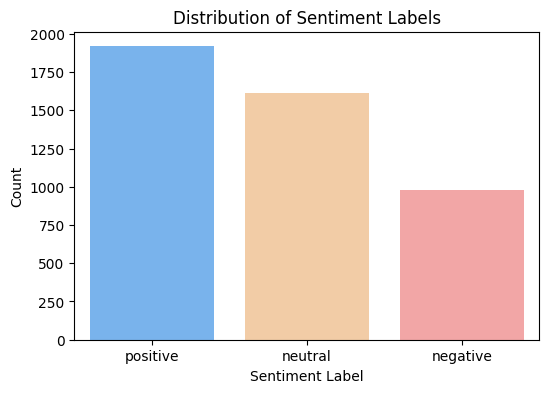

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, order=['positive', 'neutral', 'negative'],
              palette=['#66b3ff', '#ffcc99', '#ff9999'])
plt.title("Distribution of Sentiment Labels")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.show()


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-ZÀ-ÿ\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['tweet'].apply(clean_text)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42
)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
y_pred = nb_model.predict(X_test_tfidf)

In [ ]:
y_pred = nb_model.predict(X_test_tfidf)

              precision    recall  f1-score   support

    negative       0.73      0.18      0.29       198
     neutral       0.60      0.74      0.66       296
    positive       0.70      0.85      0.77       409

    accuracy                           0.66       903
   macro avg       0.68      0.59      0.57       903
weighted avg       0.68      0.66      0.63       903



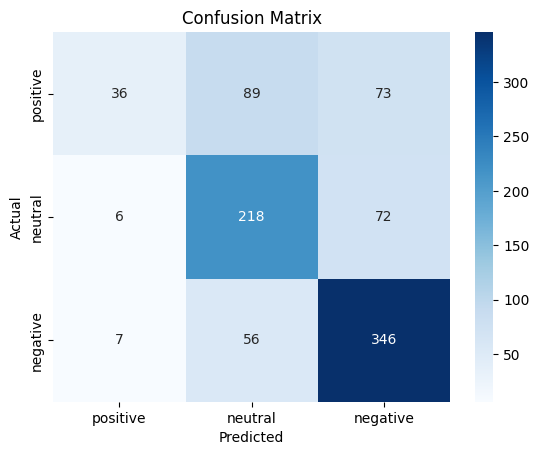

In [ ]:
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['positive','neutral','negative'], yticklabels=['positive','neutral','negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6645


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Binarize labels
y_test_bin = label_binarize(y_test, classes=['positive','neutral','negative'])
y_pred_bin = label_binarize(y_pred, classes=['positive','neutral','negative'])

roc_auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print(f"ROC-AUC (Macro, OvR): {roc_auc:.4f}")


ROC-AUC (Macro, OvR): 0.7022


In [ ]:
import joblib

joblib.dump(nb_model, 'yoruba_sentiment_nb_model.pkl')
joblib.dump(tfidf, 'yoruba_tfidf_vectorizer.pkl')


['yoruba_tfidf_vectorizer.pkl']